## 1. Data Loading

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
DATA_PATH = "../data/raw/finaldata.csv"
df = pd.read_csv(DATA_PATH)

## 2. EDA Before Cleaning (Raw Data EDA)

In [3]:
df.shape

(43853, 20)

In [4]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_ordered',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'Multiple_deliveries', 'Festival', 'City', 'Time_taken (min)'],
      dtype='object')

In [5]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_ordered,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,Multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,19-03-22,11:30:00,11:45:00,Fog,Jam,2.0,Snack,motorcycle,3.0,No,Metropolitian,46.0
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,25-03-22,19:45:00,19:50:00,Stormy,High,1.0,Meal,motorcycle,1.0,No,Metropolitian,23.0
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,19-03-22,8:30:00,8:45:00,Sandstorms,Medium,1.0,Drinks,scooter,1.0,No,Metropolitian,21.0
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,05-04-22,18:00:00,18:10:00,Sandstorms,Low,0.0,Buffet,motorcycle,0.0,No,Metropolitian,20.0
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,26-03-22,13:30:00,13:45:00,Fog,Jam,1.0,Snack,scooter,1.0,No,Metropolitian,41.0


In [6]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,Multiple_deliveries,Time_taken (min)
count,42064.000000,42011.000000,43853.000000,43853.000000,43853.000000,43853.000000,43853.000000,42890.000000,43853.000000
mean,29.567397,4.633622,17.009533,70.212749,17.460294,70.838557,1.022826,0.744766,26.299022
std,5.814316,0.335116,8.194127,22.930712,7.337792,21.132009,0.839731,0.572985,9.380741
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.546947,75.898497,18.633481,76.003400,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.728163,78.045359,22.785049,78.108890,2.000000,1.000000,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43853 entries, 0 to 43852
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           43853 non-null  object 
 1   Delivery_person_ID           43853 non-null  object 
 2   Delivery_person_Age          42064 non-null  float64
 3   Delivery_person_Ratings      42011 non-null  float64
 4   Restaurant_latitude          43853 non-null  float64
 5   Restaurant_longitude         43853 non-null  float64
 6   Delivery_location_latitude   43853 non-null  float64
 7   Delivery_location_longitude  43853 non-null  float64
 8   Order_Date                   43853 non-null  object 
 9   Time_ordered                 43853 non-null  object 
 10  Time_Order_picked            43853 non-null  object 
 11  Weather_conditions           43259 non-null  object 
 12  Road_traffic_density         43273 non-null  object 
 13  Vehicle_conditio

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df[df["Time_taken (min)"] <= 0]

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_ordered,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,Multiple_deliveries,Festival,City,Time_taken (min)


In [10]:
df["Time_ordered"] = df["Time_ordered"].str.strip()
df["Time_Order_picked"] = df["Time_Order_picked"].str.strip()
df["Order_Date"] = df["Order_Date"].str.strip()

df["Order_Date"] = pd.to_datetime(
    df["Order_Date"].astype(str).str.strip(),
    format="%d-%m-%y",
    errors="coerce"
)
df["Time_ordered"] = pd.to_datetime(
    df["Time_ordered"],
    format="%H:%M:%S",
    errors="coerce"
)

df["Time_Order_picked"] = pd.to_datetime(
    df["Time_Order_picked"],
    format="%H:%M:%S",
    errors="coerce"
)

In [11]:
df['Multiple_deliveries'] = df['Multiple_deliveries'].astype('float64')
df['Delivery_person_Age'] = df['Delivery_person_Age'].astype('float64')
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].astype('float64')

In [12]:
df.dtypes

ID                                     object
Delivery_person_ID                     object
Delivery_person_Age                   float64
Delivery_person_Ratings               float64
Restaurant_latitude                   float64
Restaurant_longitude                  float64
Delivery_location_latitude            float64
Delivery_location_longitude           float64
Order_Date                     datetime64[ns]
Time_ordered                   datetime64[ns]
Time_Order_picked              datetime64[ns]
Weather_conditions                     object
Road_traffic_density                   object
Vehicle_condition                     float64
Type_of_order                          object
Type_of_vehicle                        object
Multiple_deliveries                   float64
Festival                               object
City                                   object
Time_taken (min)                      float64
dtype: object

In [13]:
lat_min, lat_max = 8, 38
lon_min, lon_max = 68, 98

invalid_mask = (
    (df['Restaurant_latitude'] < lat_min) | (df['Restaurant_latitude'] > lat_max) |
    (df['Restaurant_longitude'] < lon_min) | (df['Restaurant_longitude'] > lon_max) |
    (df['Delivery_location_latitude'] < lat_min) | (df['Delivery_location_latitude'] > lat_max) |
    (df['Delivery_location_longitude'] < lon_min) | (df['Delivery_location_longitude'] > lon_max)
)

print("Number of invalid rows:", invalid_mask.sum())

Number of invalid rows: 3924


In [14]:
coord_cols = [
    'Restaurant_latitude',
    'Restaurant_longitude',
    'Delivery_location_latitude',
    'Delivery_location_longitude'
]

df.loc[invalid_mask, coord_cols] = np.nan

In [15]:
missing_counts = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(2)

pd.DataFrame({
    "Missing_Count": missing_counts,
    "Missing_Percent": missing_percent
}).sort_values(by="Missing_Percent", ascending=False)

,Missing_Count,Missing_Percent
Delivery_location_longitude,3924,8.95
Delivery_location_latitude,3924,8.95
Restaurant_longitude,3924,8.95
Restaurant_latitude,3924,8.95
Delivery_person_Ratings,1842,4.20
Delivery_person_Age,1789,4.08
City,1165,2.66
Multiple_deliveries,963,2.20
Weather_conditions,594,1.35
Road_traffic_density,580,1.32


## 3. Data Cleaning

### KNN Imputation for long, lat

In [16]:
knn_cols = coord_cols + ['City']

knn_df = df[knn_cols].copy()

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
knn_df['City'] = le.fit_transform(knn_df['City'].astype(str))

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(knn_df)

In [19]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
imputed = imputer.fit_transform(scaled)

In [20]:
imputed = scaler.inverse_transform(imputed)
imputed_df = pd.DataFrame(imputed, columns=knn_cols)
df[coord_cols] = imputed_df[coord_cols]

In [21]:
df[['Restaurant_latitude','Restaurant_longitude','Delivery_location_latitude','Delivery_location_longitude']].isna().sum()

Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
dtype: int64

### handling rest missing values

In [22]:
features_with_na=[features for features in df.columns if df[features].isnull().sum()>1]
features_with_na

['Delivery_person_Age',
 'Delivery_person_Ratings',
 'Weather_conditions',
 'Road_traffic_density',
 'Multiple_deliveries',
 'Festival',
 'City']

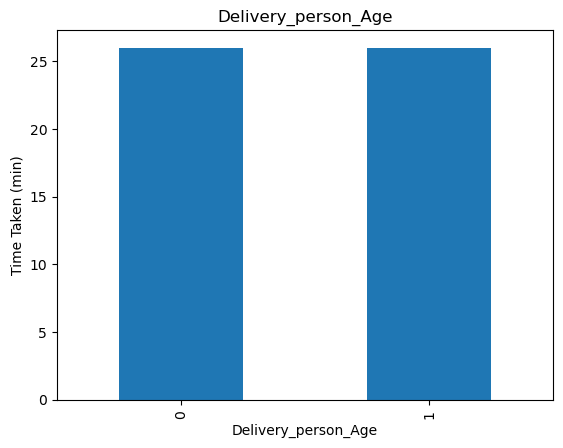

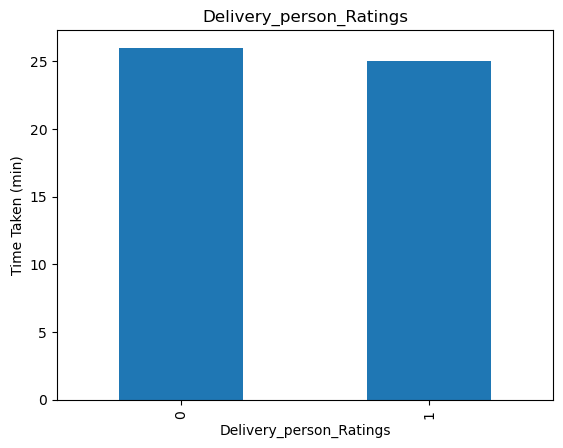

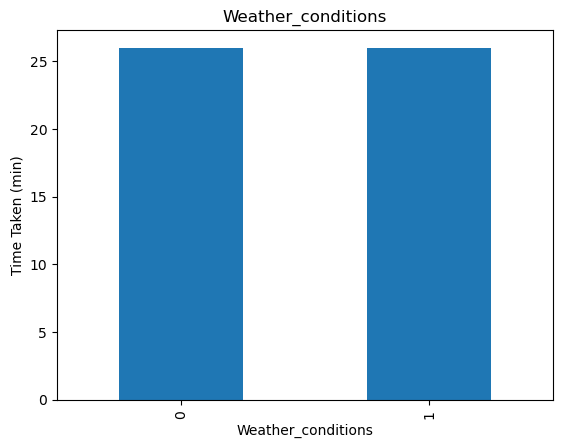

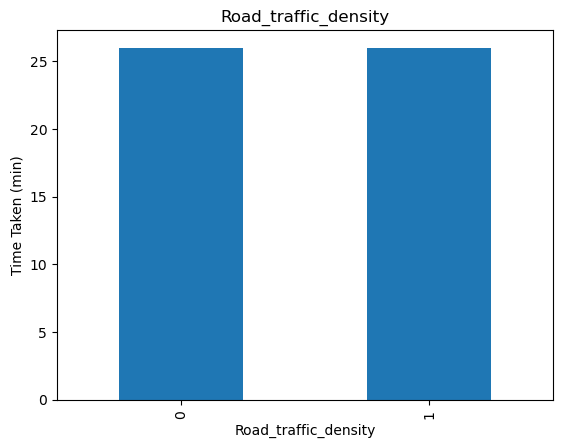

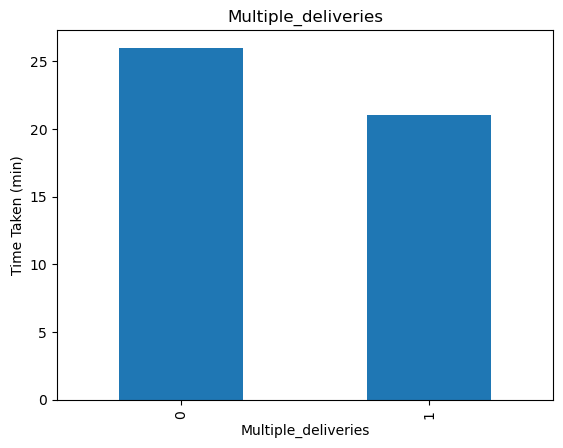

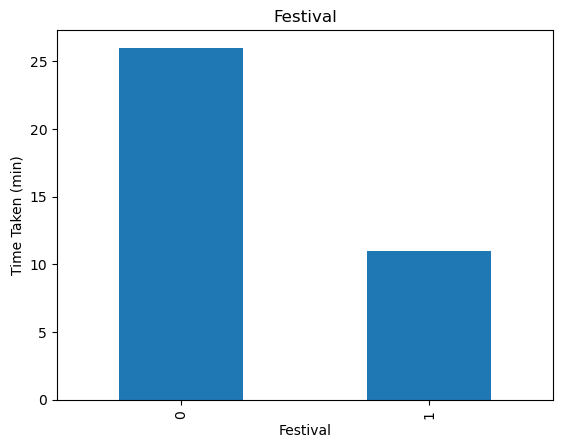

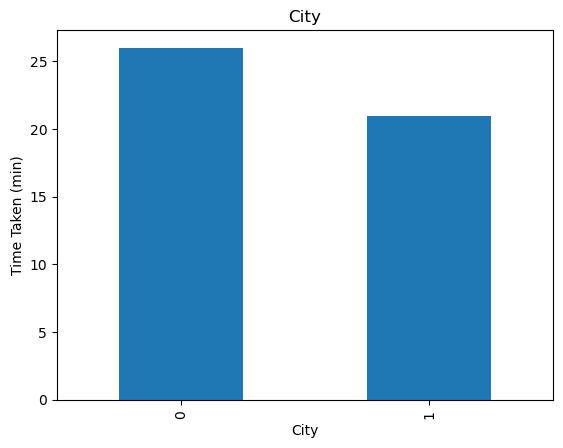

In [23]:
for feature in features_with_na:
    data = df.copy()
    
    # let's make a variable that indicates 1 if the observation was missing or zero otherwise
    data[feature] = np.where(data[feature].isnull(), 1, 0)
    
    # let's calculate the mean Time_taken (min) where the information is missing or present
    data.groupby(feature)['Time_taken (min)'].median().plot.bar()
    plt.ylabel("Time Taken (min)")
    plt.title(feature)
    plt.show()

In [24]:
# Median imputation
df['Delivery_person_Age'] = df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median())
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median())

# Mode imputation
df['Weather_conditions'] = df['Weather_conditions'].fillna(df['Weather_conditions'].mode()[0])
df['Road_traffic_density'] = df['Road_traffic_density'].fillna(df['Road_traffic_density'].mode()[0])

In [25]:
df['City'] = df['City'].replace('nan', np.nan)
df['Festival'] = df['Festival'].replace('nan', np.nan)
df['Road_traffic_density'] = df['Road_traffic_density'].replace('nan', np.nan)

In [26]:
knn_features = [
    'City',
    'Festival',
    'Multiple_deliveries',
    'Restaurant_latitude',
    'Restaurant_longitude',
    'Delivery_location_latitude',
    'Delivery_location_longitude',
    'Road_traffic_density'
]

knn_df = df[knn_features].copy()

In [27]:
category_maps = {}

for col in ['City', 'Festival', 'Road_traffic_density']:
    
    knn_df[col] = knn_df[col].astype('category')
    
    # Save original categories
    category_maps[col] = knn_df[col].cat.categories
    
    # Convert to numeric codes
    knn_df[col] = knn_df[col].cat.codes
    
    # Replace -1 (NaN) with np.nan
    knn_df[col] = knn_df[col].replace(-1, np.nan)

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
knn_scaled = scaler.fit_transform(knn_df)

In [29]:
df['Festival'].isna().sum()

np.int64(218)

In [30]:
df['City'].isna().sum()

np.int64(1165)

In [31]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
knn_imputed = imputer.fit_transform(knn_scaled)

In [32]:
knn_imputed = scaler.inverse_transform(knn_imputed)

knn_imputed_df = pd.DataFrame(knn_imputed, columns=knn_df.columns)

In [33]:
categorical_cols = ['City', 'Festival', 'Road_traffic_density']

for col in categorical_cols:
    knn_imputed_df[col] = knn_imputed_df[col].round().astype(int)

for col in categorical_cols:
    knn_imputed_df[col] = pd.Categorical.from_codes(
        knn_imputed_df[col],
        categories=category_maps[col]
    )

In [34]:
df[categorical_cols] = knn_imputed_df[categorical_cols]

In [35]:
knn_features_md = [
    'Multiple_deliveries',
    'Restaurant_latitude',
    'Restaurant_longitude',
    'Delivery_location_latitude',
    'Delivery_location_longitude'
]

knn_df1 = df[knn_features_md].copy()

In [36]:
from sklearn.preprocessing import StandardScaler

scaler_md = StandardScaler()
knn_scaled_md = scaler_md.fit_transform(knn_df1)

In [37]:
imputer = KNNImputer(n_neighbors=5)

knn_imputed = imputer.fit_transform(knn_scaled_md)

In [38]:
knn_imputed = scaler_md.inverse_transform(knn_imputed)

knn_imputed_df = pd.DataFrame(
    knn_imputed,
    columns=knn_features_md
)

In [39]:
knn_imputed_df["Multiple_deliveries"] = (
    knn_imputed_df["Multiple_deliveries"]
    .round()
    .clip(lower=0)
    .astype(int)
)

In [40]:
df["Multiple_deliveries"] = knn_imputed_df["Multiple_deliveries"]

In [41]:
 df[features_with_na].isnull().sum()

Delivery_person_Age        0
Delivery_person_Ratings    0
Weather_conditions         0
Road_traffic_density       0
Multiple_deliveries        0
Festival                   0
City                       0
dtype: int64

In [42]:
# Convert degrees to radians
lat1 = np.radians(df['Restaurant_latitude'])
lon1 = np.radians(df['Restaurant_longitude'])
lat2 = np.radians(df['Delivery_location_latitude'])
lon2 = np.radians(df['Delivery_location_longitude'])

# Haversine formula
dlat = lat2 - lat1
dlon = lon2 - lon1

a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
c = 2 * np.arcsin(np.sqrt(a))

# Earth radius in kilometers
R = 6371

df['distance_km'] = R * c
df['distance_km'].describe()

count    43853.000000
mean        10.051545
std          5.507991
min          1.465067
25%          5.875219
50%         10.088442
75%         13.989852
max         20.969489
Name: distance_km, dtype: float64

### 4. Outlier Analysis

In [43]:
df['Time_taken (min)'].describe()

count    43853.000000
mean        26.299022
std          9.380741
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken (min), dtype: float64

<Axes: xlabel='Time_taken (min)'>

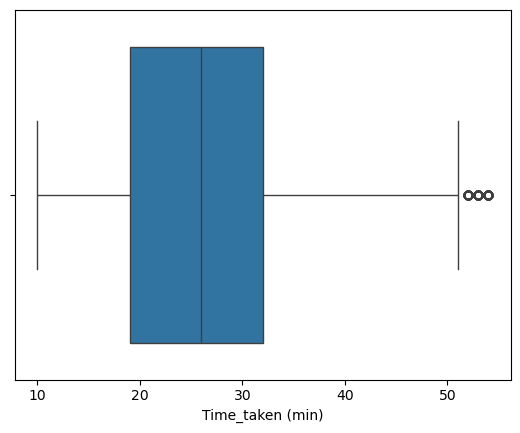

In [44]:
sns.boxplot(x=df['Time_taken (min)'])

In [45]:
df['distance_km'].describe()

count    43853.000000
mean        10.051545
std          5.507991
min          1.465067
25%          5.875219
50%         10.088442
75%         13.989852
max         20.969489
Name: distance_km, dtype: float64

<Axes: xlabel='distance_km'>

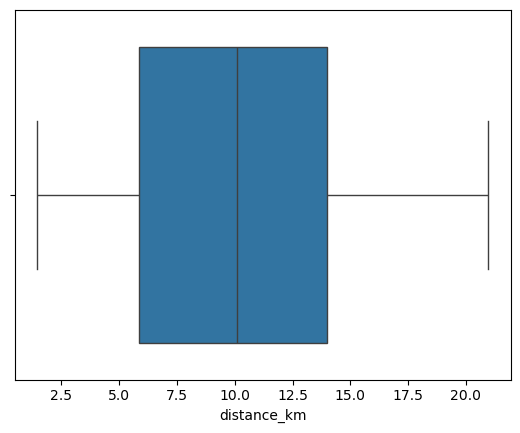

In [46]:
sns.boxplot(x=df['distance_km'])

In [47]:
df['Delivery_person_Age'].describe()

count    43853.000000
mean        29.585045
std          5.695122
min         15.000000
25%         25.000000
50%         30.000000
75%         34.000000
max         50.000000
Name: Delivery_person_Age, dtype: float64

<Axes: xlabel='Delivery_person_Age'>

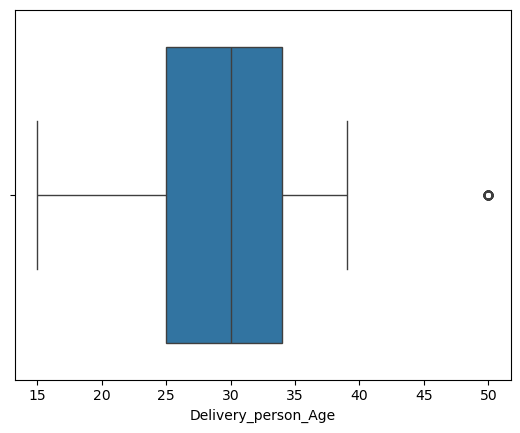

In [48]:
sns.boxplot(x=df['Delivery_person_Age'])

In [49]:
df[['distance_km','Time_taken (min)']].corr()

,distance_km,Time_taken (min)
distance_km,1.000000,0.304747
Time_taken (min),0.304747,1.000000


In [50]:
df['speed_kmph'] = df['distance_km'] / (df['Time_taken (min)'] / 60)
df['speed_kmph'].describe()

count    43853.000000
mean        24.775472
std         15.973755
min          1.696010
25%         13.323769
50%         21.734036
75%         32.712950
max        125.121922
Name: speed_kmph, dtype: float64

In [51]:
df[df['speed_kmph'] > 80].shape

(342, 22)

In [52]:
df = df[df['speed_kmph'] <= 80]

In [53]:
df['Delivery_person_Ratings'].describe()

count    43511.000000
mean         4.635403
std          0.329122
min          1.000000
25%          4.500000
50%          4.700000
75%          4.800000
max          6.000000
Name: Delivery_person_Ratings, dtype: float64

In [54]:
(df['Delivery_person_Ratings'] > 5).sum()

np.int64(52)

In [55]:
df.loc[df['Delivery_person_Ratings'] > 5, 'Delivery_person_Ratings'] = 5

In [56]:
df['Multiple_deliveries'].describe()

count    43511.000000
mean         0.749374
std          0.569668
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          3.000000
Name: Multiple_deliveries, dtype: float64

In [57]:
df['Vehicle_condition'].describe()

count    43511.000000
mean         1.019328
std          0.840603
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          3.000000
Name: Vehicle_condition, dtype: float64

In [58]:
(df['Time_Order_picked'] < df['Time_ordered']).sum()

np.int64(819)

In [59]:
df['Time_ordered'] = df['Time_ordered'].dt.time
df['Time_Order_picked'] = df['Time_Order_picked'].dt.time
df['Time_ordered'] = pd.to_timedelta(df['Time_ordered'].astype(str))
df['Time_Order_picked'] = pd.to_timedelta(df['Time_Order_picked'].astype(str))
df['Order_datetime'] = (
    df['Order_Date'] + df['Time_ordered']
)

df['Pickup_datetime'] = (
    df['Order_Date'] + df['Time_Order_picked']
)

In [60]:
mask = df['Pickup_datetime'] < df['Order_datetime']
df.loc[mask, 'Pickup_datetime'] += pd.Timedelta(days=1)

In [61]:
(df['Pickup_datetime'] < df['Order_datetime']).sum()

np.int64(0)

In [62]:
df['Weather_conditions'].value_counts()

Weather_conditions
Fog           7936
Cloudy        7247
Stormy        7211
Sandstorms    7130
Windy         7093
Sunny         6894
Name: count, dtype: int64

In [63]:
df['Road_traffic_density'].value_counts()

Road_traffic_density
Low       15264
Jam       13508
Medium    10503
High       4236
Name: count, dtype: int64

In [64]:
df['Festival'].value_counts()

Festival
No     42644
Yes      867
Name: count, dtype: int64

In [65]:
df['City'].value_counts()

City
Metropolitian    33305
Urban             9648
Semi-Urban         558
Name: count, dtype: int64

In [66]:
df.duplicated().sum()
df['ID'].duplicated().sum()

np.int64(0)

## 5. Feature Engineering

In [67]:
df['Order_hour'] = df['Order_datetime'].dt.hour

In [68]:
df['Is_weekend'] = (
    df['Order_datetime'].dt.dayofweek >= 5
).astype(int)

In [69]:
hour_dist = df['Order_hour'].value_counts(normalize=True)

peak_hours = hour_dist[hour_dist > hour_dist.mean()].index

df['Is_Peak_Hour'] = df['Order_hour'].isin(peak_hours).astype(int)

In [70]:
df['Is_late_night'] = (
    (df['Order_hour'] >= 23) | (df['Order_hour'] <= 4)
).astype(int)

In [71]:
df['Prep_time_min'] = (
    df['Pickup_datetime'] - df['Order_datetime']
).dt.total_seconds() / 60

In [72]:
df['Traffic_peak_combo'] = (
    df['Road_traffic_density'].astype(str) + "_" +
    df['Is_Peak_Hour'].astype(str)
)

In [73]:
df['Vehicle_combo'] = (
    df['Type_of_vehicle'].astype(str) + "_" +
    df['Vehicle_condition'].astype(str)
)

In [74]:
df['Is_festival'] = (df['Festival'].astype(str) == 'Yes').astype(int)
df = df.drop(columns=['Festival'])

In [75]:
df.dtypes

ID                                      object
Delivery_person_ID                      object
Delivery_person_Age                    float64
Delivery_person_Ratings                float64
Restaurant_latitude                    float64
Restaurant_longitude                   float64
Delivery_location_latitude             float64
Delivery_location_longitude            float64
Order_Date                      datetime64[ns]
Time_ordered                   timedelta64[ns]
Time_Order_picked              timedelta64[ns]
Weather_conditions                      object
Road_traffic_density                  category
Vehicle_condition                      float64
Type_of_order                           object
Type_of_vehicle                         object
Multiple_deliveries                      int64
City                                  category
Time_taken (min)                       float64
distance_km                            float64
speed_kmph                             float64
Order_datetim

## 6. Remove Leakage & Irrelevant Columns

In [76]:
cols_to_drop = [
    "ID", "Delivery_person_ID",
    "Order_Date", "Time_ordered", "Time_Order_picked",
    "Order_datetime", "Pickup_datetime", "Restaurant_latitude", "Restaurant_longitude", "Delivery_location_latitude", "Delivery_location_longitude"
]

df = df.drop(columns=cols_to_drop)

## 7. Target Creation

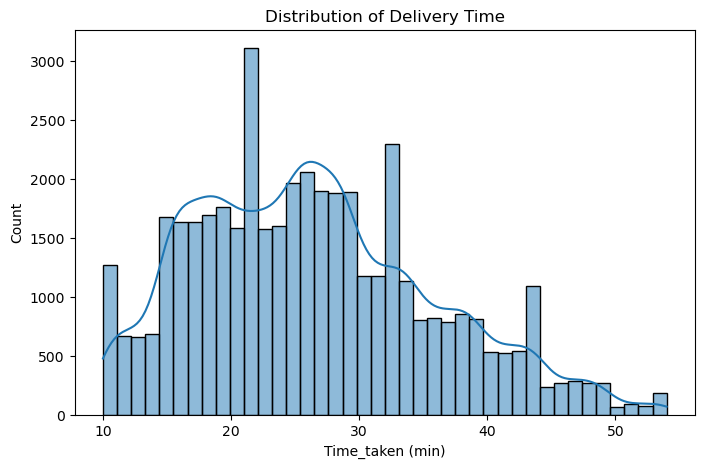

count    43511.000000
mean        26.412126
std          9.328724
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken (min), dtype: float64

In [77]:
plt.figure(figsize=(8,5))
sns.histplot(df["Time_taken (min)"], bins=40, kde=True)
plt.title("Distribution of Delivery Time")
plt.show()

df["Time_taken (min)"].describe()

In [78]:
df["Time_per_km"] = df["Time_taken (min)"] / df["distance_km"]

In [79]:
p75 = df["Time_per_km"].quantile(0.75)
p90 = df["Time_per_km"].quantile(0.90)

def classify_efficiency(x):
    if x <= p75:
        return "On-Time"
    elif x <= p90:
        return "At-Risk"
    else:
        return "Delayed"

df["Delivery_Status"] = df["Time_per_km"].apply(classify_efficiency)

df["Delivery_Status"].value_counts(normalize=True)

Delivery_Status
On-Time    0.749994
At-Risk    0.150008
Delayed    0.099998
Name: proportion, dtype: float64

In [80]:
df.groupby("Delivery_Status")["Time_per_km"].agg(["min", "max", "mean", "median"])

,min,max,mean,median
Delivery_Status,,,,
At-Risk,4.509364,8.390683,6.028144,5.856254
Delayed,8.390923,35.377140,13.609015,12.364191
On-Time,0.750877,4.509357,2.398000,2.279837


## 8. Final Correlation & Redundancy Check

<Axes: >

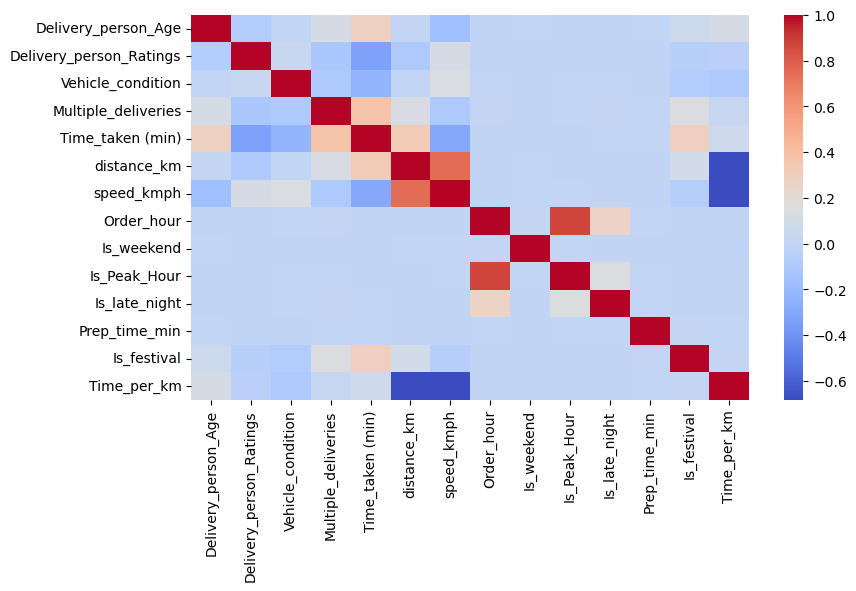

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm")

In [82]:
to_drop = [
    'speed_kmph','Order_hour','Time_taken (min)','Time_per_km'
]
df = df.drop(columns=to_drop)

## 9. Train-Test splitting

In [83]:
df.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Weather_conditions',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'Multiple_deliveries', 'City', 'distance_km',
       'Is_weekend', 'Is_Peak_Hour', 'Is_late_night', 'Prep_time_min',
       'Traffic_peak_combo', 'Vehicle_combo', 'Is_festival',
       'Delivery_Status'],
      dtype='object')

In [84]:
X = df.drop(columns=["Delivery_Status"])
y = df["Delivery_Status"]

In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [86]:
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Train distribution:
Delivery_Status
On-Time    0.750000
At-Risk    0.149994
Delayed    0.100006
Name: proportion, dtype: float64

Test distribution:
Delivery_Status
On-Time    0.749971
At-Risk    0.150063
Delayed    0.099966
Name: proportion, dtype: float64


In [87]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class Mapping:", class_mapping)

Class Mapping: {'At-Risk': np.int64(0), 'Delayed': np.int64(1), 'On-Time': np.int64(2)}


## 10. Identifying features types

In [88]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: ['Delivery_person_Age', 'Delivery_person_Ratings', 'Vehicle_condition', 'Multiple_deliveries', 'distance_km', 'Is_weekend', 'Is_Peak_Hour', 'Is_late_night', 'Prep_time_min', 'Is_festival']
Categorical: ['Weather_conditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'City', 'Traffic_peak_combo', 'Vehicle_combo']


## 11. Scaling and Encoding 

In [89]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [90]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [99]:
from sklearn.model_selection import train_test_split

X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train,
    y_train_encoded,
    test_size=0.25,
    stratify=y_train_encoded,
    random_state=42
)

print("Train:", X_train_main.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (26106, 17)
Validation: (8702, 17)
Test: (8703, 17)


In [100]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

pipe_knn = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

pipe_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42
    ))
])

In [101]:
feature_names = preprocessor.get_feature_names_out()
print(feature_names[:20])

['num__Delivery_person_Age' 'num__Delivery_person_Ratings'
 'num__Vehicle_condition' 'num__Multiple_deliveries' 'num__distance_km'
 'num__Is_weekend' 'num__Is_Peak_Hour' 'num__Is_late_night'
 'num__Prep_time_min' 'num__Is_festival' 'cat__Weather_conditions_Cloudy'
 'cat__Weather_conditions_Fog' 'cat__Weather_conditions_Sandstorms'
 'cat__Weather_conditions_Stormy' 'cat__Weather_conditions_Sunny'
 'cat__Weather_conditions_Windy' 'cat__Road_traffic_density_High'
 'cat__Road_traffic_density_Jam' 'cat__Road_traffic_density_Low'
 'cat__Road_traffic_density_Medium']


## 12. Class Imbalance Diagnostics

In [105]:
print(np.unique(y_train_main))
print(np.isnan(y_train_main).sum())

class_counts = pd.Series(y_train_main).value_counts()
print(class_counts)

class_percent = pd.Series(y_train_main).value_counts(normalize=True) * 100
print(class_percent.round(2))

imbalance_ratio = class_counts.max() / class_counts.min()
print("Imbalance Ratio:", round(imbalance_ratio, 2))

[0 1 2]
0
2    19579
0     3916
1     2611
Name: count, dtype: int64
2    75.0
0    15.0
1    10.0
Name: proportion, dtype: float64
Imbalance Ratio: 7.5


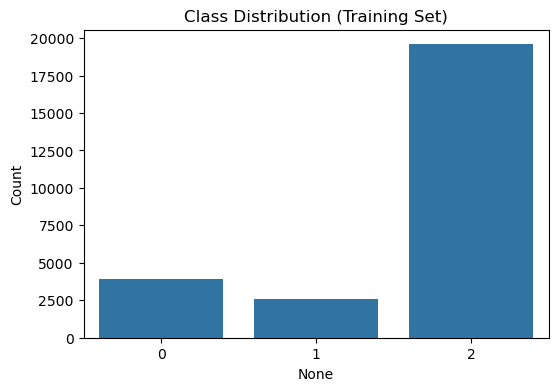

In [106]:
plt.figure(figsize=(6,4))
sns.countplot(x=pd.Series(y_train_main))
plt.title("Class Distribution (Training Set)")
plt.ylabel("Count")
plt.show()

#### Baseline

In [109]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import pandas as pd

results = []

models = {
    "Logistic Regression": pipe_lr,
    "Random Forest": pipe_rf,
    "KNN": pipe_knn,
    "XGBoost": pipe_xgb
}

for name, pipe in models.items():
    
    print(f"\n===== {name} (Baseline) =====")
    
    # train
    pipe.fit(X_train_main, y_train_main)
    
    # predict on validation
    y_val_pred = pipe.predict(X_val)
    
    # metrics
    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred, average="macro")
    
    print("Accuracy:", round(acc,4))
    print("F1 score(macro):", round(f1,4))
    
    print("\nClassification Report:")
    print(classification_report(y_val, y_val_pred))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_val, y_val_pred))
    
    results.append({
        "Model": name,
        "Technique": "Baseline",
        "Accuracy": acc,
        "F1": f1
    })

results_df = pd.DataFrame(results)
results_df


===== Logistic Regression (Baseline) =====
Accuracy: 0.9109
F1 score(macro): 0.8404

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.70      0.70      1305
           1       0.86      0.86      0.86       870
           2       0.96      0.96      0.96      6527

    accuracy                           0.91      8702
   macro avg       0.84      0.84      0.84      8702
weighted avg       0.91      0.91      0.91      8702


Confusion Matrix:
[[ 910  122  273]
 [ 120  749    1]
 [ 259    0 6268]]

===== Random Forest (Baseline) =====
Accuracy: 0.9219
F1 score(macro): 0.8542

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.71      0.73      1305
           1       0.85      0.87      0.86       870
           2       0.96      0.97      0.97      6527

    accuracy                           0.92      8702
   macro avg       0.86      0.85      0.85      8702
weighte

,Model,Technique,Accuracy,F1
0,Logistic Regression,Baseline,0.910940,0.840420
1,Random Forest,Baseline,0.921857,0.854237
2,KNN,Baseline,0.808435,0.606573
3,XGBoost,Baseline,0.927948,0.864813


Evaluation

In [110]:
from sklearn.metrics import accuracy_score, f1_score, recall_score
import pandas as pd

results = []

models = {
    "Logistic Regression": pipe_lr,
    "Random Forest": pipe_rf,
    "KNN": pipe_knn,
    "XGBoost": pipe_xgb
}

for name, pipe in models.items():
    
    pipe.fit(X_train_main, y_train_main)
    y_pred = pipe.predict(X_val)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Macro_F1": f1_score(y_val, y_pred, average="macro"),
        "Weighted_F1": f1_score(y_val, y_pred, average="weighted"),
        "Recall_Class0": recall_score(y_val, y_pred, average=None)[0],
        "Recall_Class1": recall_score(y_val, y_pred, average=None)[1],
        "Recall_Class2": recall_score(y_val, y_pred, average=None)[2],
    })

metrics_df = pd.DataFrame(results)
metrics_df

,Model,Accuracy,Macro_F1,Weighted_F1,Recall_Class0,Recall_Class1,Recall_Class2
0,Logistic Regression,0.910940,0.840420,0.910709,0.697318,0.860920,0.960319
1,Random Forest,0.921857,0.854237,0.920917,0.711877,0.871264,0.970584
2,KNN,0.808435,0.606573,0.801569,0.375479,0.474713,0.939482
3,XGBoost,0.927948,0.864813,0.928012,0.764751,0.857471,0.969971


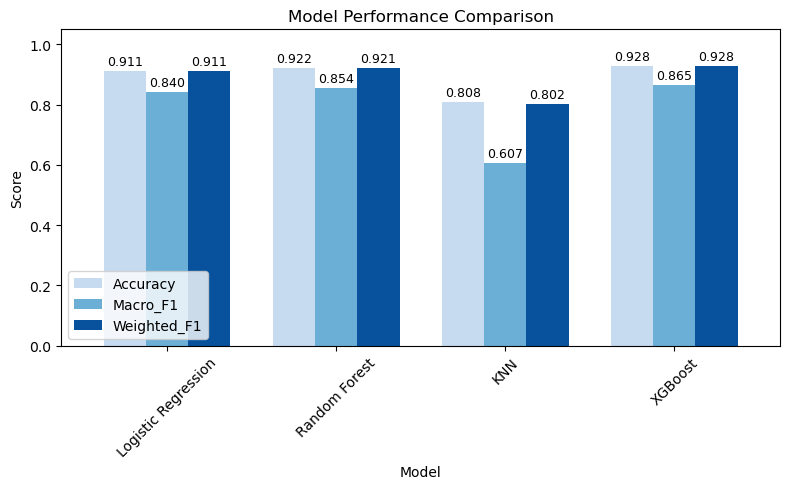

In [112]:
import matplotlib.pyplot as plt
import numpy as np

data = metrics_df.set_index("Model")[["Accuracy","Macro_F1","Weighted_F1"]]

colors = ["#c6dbef", "#6baed6", "#08519c"]  # light → dark blue shades

ax = data.plot(
    kind="bar",
    figsize=(8,5),
    color=colors,
    width=0.75
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0,1.05)
plt.legend()

# add value labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

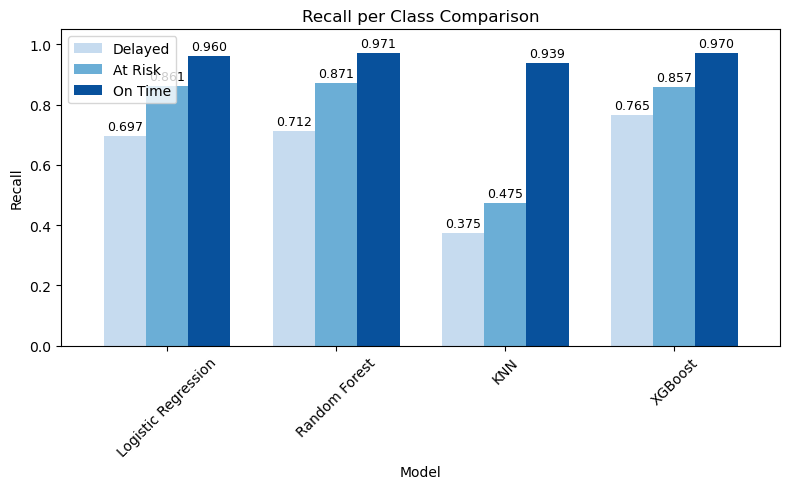

In [115]:
import matplotlib.pyplot as plt

data = metrics_df.set_index("Model")[[
    "Recall_Class0",
    "Recall_Class1",
    "Recall_Class2"
]]

colors = ["#c6dbef", "#6baed6", "#08519c"]  # light → medium → dark blue

ax = data.plot(
    kind="bar",
    figsize=(8,5),
    color=colors,
    width=0.75
)

plt.title("Recall per Class Comparison")
plt.ylabel("Recall")
plt.xticks(rotation=45)
plt.ylim(0,1.05)
plt.legend(["Delayed","At Risk","On Time"])

# add value labels on bars
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

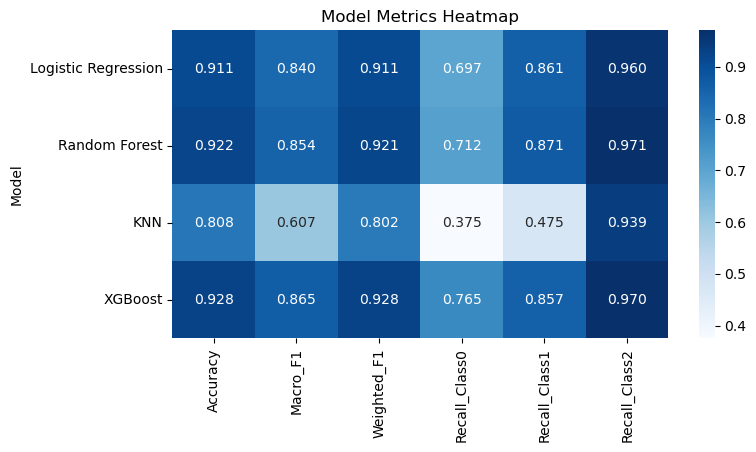

In [116]:
import seaborn as sns

plt.figure(figsize=(8,4))
sns.heatmap(
    metrics_df.set_index("Model"),
    annot=True,
    fmt=".3f",
    cmap="Blues"
)
plt.title("Model Metrics Heatmap")
plt.show()

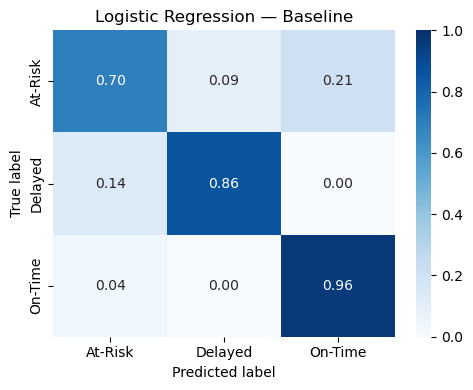

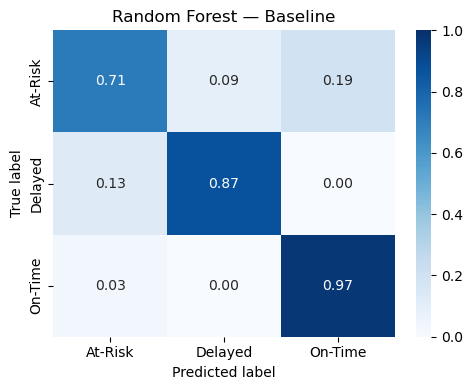

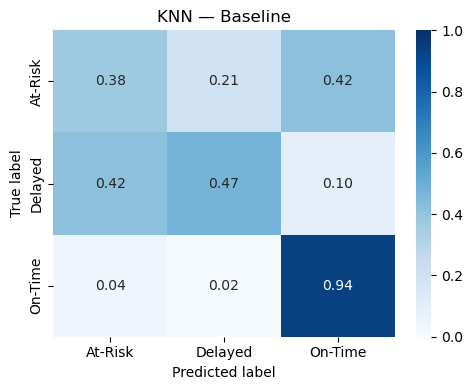

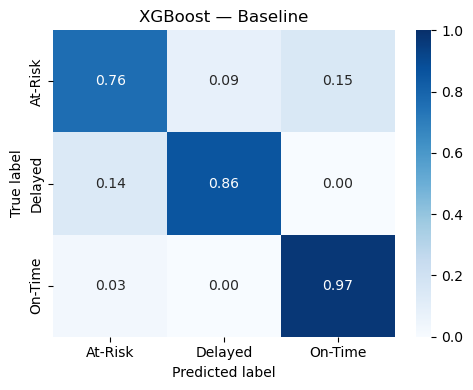

In [120]:
models = {
    "Logistic Regression": pipe_lr,
    "Random Forest": pipe_rf,
    "KNN": pipe_knn,
    "XGBoost": pipe_xgb
}

class_names = ["At-Risk", "Delayed", "On-Time"]

for name, pipe in models.items():
    
    # prediction (no retraining, just inference)
    y_pred = pipe.predict(X_val)
    
    # confusion matrix normalized by row
    cm = confusion_matrix(y_val, y_pred)
    cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(5,4))
    
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        vmin=0,
        vmax=1
    )
    
    plt.title(f"{name} — Baseline")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    
    plt.tight_layout()
    plt.show()

#### Class Weights

In [121]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# compute weights automatically
classes = np.unique(y_train_main)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_main
)

class_weight_dict = dict(zip(classes, weights))

print(class_weight_dict)

{np.int64(0): np.float64(2.2221654749744637), np.int64(1): np.float64(3.332822673305247), np.int64(2): np.float64(0.4444557944736708)}


In [124]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd

weighted_results = []
weighted_preds = {}

models_weighted = {
    "Logistic Regression": pipe_lr_w,
    "Random Forest": pipe_rf_w,
    "XGBoost": pipe_xgb_w
}

# sample weights needed for XGBoost
sample_weights = np.array([class_weight_dict[y] for y in y_train_main])

for name, pipe in models_weighted.items():
    
    print(f"\n===== {name} (Class Weight) =====")
    
    # train
    if name == "XGBoost":
        pipe.fit(
            X_train_main,
            y_train_main,
            model__sample_weight=sample_weights
        )
    else:
        pipe.fit(X_train_main, y_train_main)
    
    # predict
    y_val_pred = pipe.predict(X_val)
    
    weighted_preds[name] = y_val_pred
    
    # metrics
    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred, average="macro")
    
    print("Accuracy:", round(acc,4))
    print("F1 score(macro):", round(f1,4))
    
    print("\nClassification Report:")
    print(classification_report(y_val, y_val_pred))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_val, y_val_pred))
    
    weighted_results.append({
        "Model": name,
        "Technique": "Class Weight",
        "Accuracy": acc,
        "F1": f1
    })

weighted_df = pd.DataFrame(weighted_results)
weighted_df


===== Logistic Regression (Class Weight) =====
Accuracy: 0.8842
F1 score(macro): 0.8286

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.84      0.68      1305
           1       0.84      0.89      0.86       870
           2       0.99      0.89      0.94      6527

    accuracy                           0.88      8702
   macro avg       0.80      0.87      0.83      8702
weighted avg       0.91      0.88      0.89      8702


Confusion Matrix:
[[1092  151   62]
 [  94  776    0]
 [ 699    2 5826]]

===== Random Forest (Class Weight) =====
Accuracy: 0.9212
F1 score(macro): 0.8525

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.70      0.73      1305
           1       0.86      0.87      0.87       870
           2       0.96      0.97      0.97      6527

    accuracy                           0.92      8702
   macro avg       0.86      0.84      0.85      8702

,Model,Technique,Accuracy,F1
0,Logistic Regression,Class Weight,0.884165,0.828628
1,Random Forest,Class Weight,0.921168,0.852482
2,XGBoost,Class Weight,0.919559,0.863117


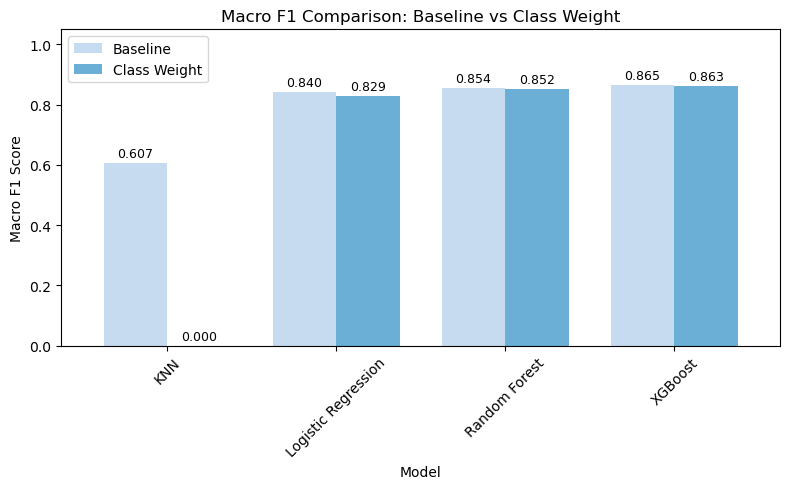

In [126]:
import matplotlib.pyplot as plt
import pandas as pd

# combine both results
comparison_df = pd.concat([results_df, weighted_df], ignore_index=True)

# pivot using your column name "F1"
data = comparison_df.pivot(
    index="Model",
    columns="Technique",
    values="F1"
)

colors = ["#c6dbef", "#6baed6"]  # light and darker blue

ax = data.plot(
    kind="bar",
    figsize=(8,5),
    color=colors,
    width=0.75
)

plt.title("Macro F1 Comparison: Baseline vs Class Weight")
plt.ylabel("Macro F1 Score")
plt.xticks(rotation=45)
plt.ylim(0,1.05)

# add values on bars
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if not pd.isna(height):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.01,
                f"{height:.3f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

plt.legend()
plt.tight_layout()
plt.show()

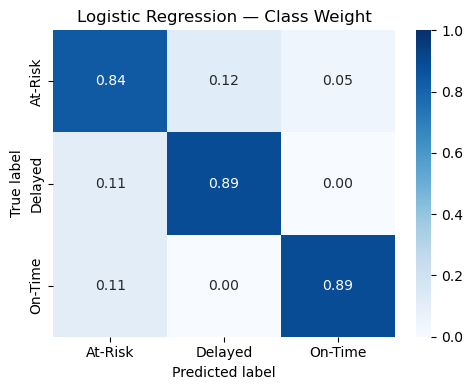

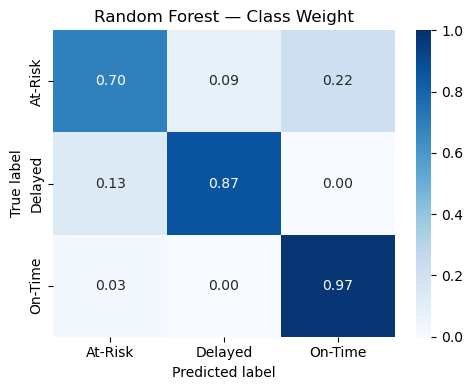

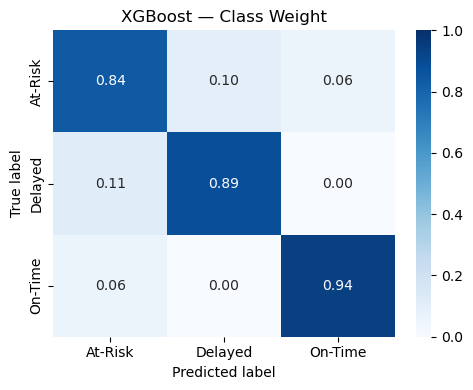

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

class_names = ["At-Risk", "Delayed", "On-Time"]

for name, y_pred in weighted_preds.items():
    
    cm = confusion_matrix(y_val, y_pred)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    
    plt.figure(figsize=(5,4))
    
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        vmin=0,
        vmax=1
    )
    
    plt.title(f"{name} — Class Weight")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    
    plt.tight_layout()
    plt.show()

#### SMOTE

In [128]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

smote = SMOTE(random_state=42)

pipe_lr_s = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", smote),
    ("model", LogisticRegression(max_iter=1000))
])

pipe_rf_s = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", smote),
    ("model", RandomForestClassifier(random_state=42))
])

pipe_knn_s = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", smote),
    ("model", KNeighborsClassifier())
])

pipe_xgb_s = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", smote),
    ("model", XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42
    ))
])

In [129]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd

smote_results = []
smote_preds = {}

models_smote = {
    "Logistic Regression": pipe_lr_s,
    "Random Forest": pipe_rf_s,
    "KNN": pipe_knn_s,
    "XGBoost": pipe_xgb_s
}

for name, pipe in models_smote.items():
    
    print(f"\n===== {name} (SMOTE) =====")
    
    # train
    pipe.fit(X_train_main, y_train_main)
    
    # predict
    y_val_pred = pipe.predict(X_val)
    
    smote_preds[name] = y_val_pred
    
    # metrics
    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred, average="macro")
    
    print("Accuracy:", round(acc,4))
    print("F1 score(macro):", round(f1,4))
    
    print("\nClassification Report:")
    print(classification_report(y_val, y_val_pred))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_val, y_val_pred))
    
    smote_results.append({
        "Model": name,
        "Technique": "SMOTE",
        "Accuracy": acc,
        "F1": f1
    })

smote_df = pd.DataFrame(smote_results)
smote_df


===== Logistic Regression (SMOTE) =====
Accuracy: 0.8928
F1 score(macro): 0.8371

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.84      0.70      1305
           1       0.85      0.88      0.87       870
           2       0.99      0.91      0.94      6527

    accuracy                           0.89      8702
   macro avg       0.81      0.88      0.84      8702
weighted avg       0.92      0.89      0.90      8702


Confusion Matrix:
[[1094  135   76]
 [ 102  768    0]
 [ 618    2 5907]]

===== Random Forest (SMOTE) =====
Accuracy: 0.9236
F1 score(macro): 0.8628

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.77      0.75      1305
           1       0.86      0.88      0.87       870
           2       0.97      0.96      0.97      6527

    accuracy                           0.92      8702
   macro avg       0.86      0.87      0.86      8702
weighted avg 

,Model,Technique,Accuracy,F1
0,Logistic Regression,SMOTE,0.892783,0.837075
1,Random Forest,SMOTE,0.923581,0.862826
2,KNN,SMOTE,0.722133,0.577811
3,XGBoost,SMOTE,0.925305,0.861887


In [130]:
comparison_df = pd.concat(
    [results_df, weighted_df, smote_df],
    ignore_index=True
)

comparison_df

,Model,Technique,Accuracy,F1
0,Logistic Regression,Baseline,0.910940,0.840420
1,Random Forest,Baseline,0.921857,0.854237
2,KNN,Baseline,0.808435,0.606573
3,XGBoost,Baseline,0.927948,0.864813
4,Logistic Regression,Class Weight,0.884165,0.828628
5,Random Forest,Class Weight,0.921168,0.852482
6,XGBoost,Class Weight,0.919559,0.863117
7,Logistic Regression,SMOTE,0.892783,0.837075
8,Random Forest,SMOTE,0.923581,0.862826
9,KNN,SMOTE,0.722133,0.577811


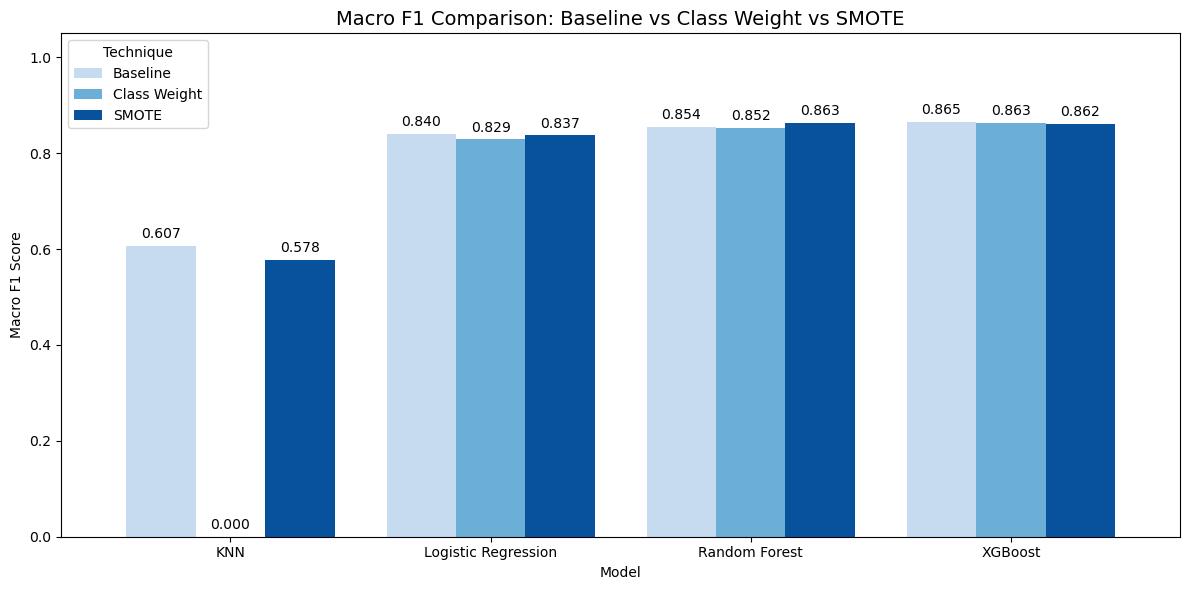

In [132]:
import matplotlib.pyplot as plt

data = comparison_df.pivot(
    index="Model",
    columns="Technique",
    values="F1"
)

colors = ["#c6dbef", "#6baed6", "#08519c"]

ax = data.plot(
    kind="bar",
    figsize=(12,6),   # wider figure
    color=colors,
    width=0.8         # wider bars
)

plt.title("Macro F1 Comparison: Baseline vs Class Weight vs SMOTE", fontsize=14)
plt.ylabel("Macro F1 Score")
plt.xticks(rotation=0)
plt.ylim(0,1.05)

# add values on bars
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height == height:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.01,
                f"{height:.3f}",
                ha="center",
                va="bottom",
                fontsize=10
            )

plt.legend(title="Technique")
plt.tight_layout()
plt.show()

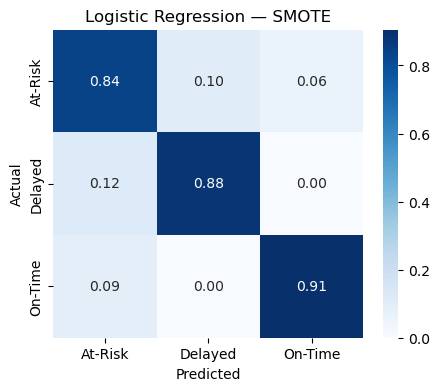

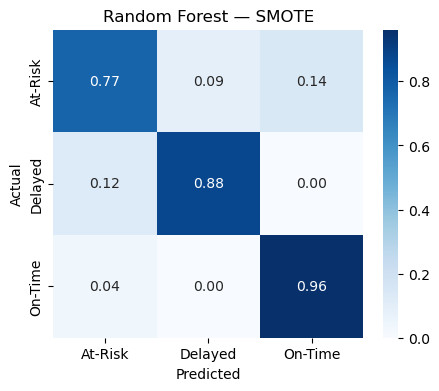

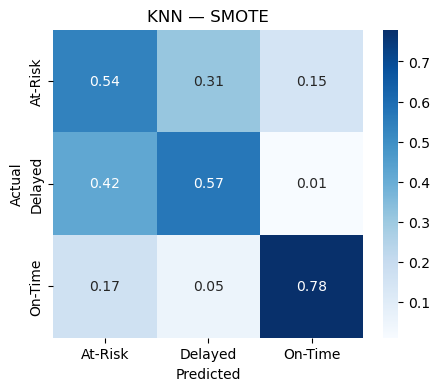

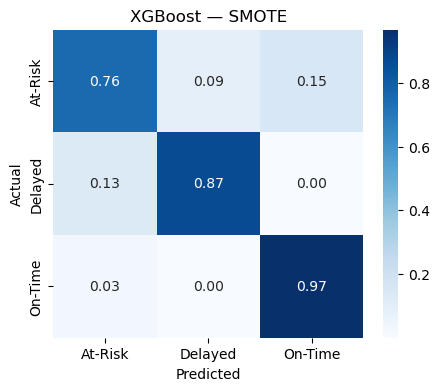

In [133]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

class_names = ["At-Risk","Delayed","On-Time"]

for name, y_pred in smote_preds.items():
    
    cm = confusion_matrix(y_val, y_pred)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    
    plt.figure(figsize=(5,4))
    
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    
    plt.title(f"{name} — SMOTE")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plt.show()

#### Hyperparameter tuning for XGBoost Baseline version

In [134]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

pipe_xgb_tune = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42
    ))
])

In [135]:
param_grid_xgb = {

    "model__n_estimators": [100, 200, 300],

    "model__max_depth": [4, 6, 8],

    "model__learning_rate": [0.03, 0.1],

    "model__subsample": [0.8, 1.0],

    "model__colsample_bytree": [0.8, 1.0]
}

In [136]:
from sklearn.model_selection import GridSearchCV

grid_xgb = GridSearchCV(

    estimator=pipe_xgb_tune,

    param_grid=param_grid_xgb,

    scoring="f1_macro",

    cv=5,

    n_jobs=-1,

    verbose=2
)

grid_xgb.fit(X_train_main, y_train_main)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,estimator,"Pipeline(step...ass=3, ...))])"
,param_grid,"{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.03, 0.1], 'model__max_depth': [4, 6, ...], 'model__n_estimators': [100, 200, ...], ...}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [137]:
print("Best Parameters:")
print(grid_xgb.best_params_)

print("\nBest CV Macro F1:")
print(grid_xgb.best_score_)

Best Parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 8, 'model__n_estimators': 200, 'model__subsample': 0.8}

Best CV Macro F1:
0.8722137288708016


In [138]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

best_xgb = grid_xgb.best_estimator_

y_val_pred = best_xgb.predict(X_val)

print("\nValidation Accuracy:",
      accuracy_score(y_val, y_val_pred))

print("\nValidation Macro F1:",
      f1_score(y_val, y_val_pred, average="macro"))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))


Validation Accuracy: 0.9311652493679614

Validation Macro F1: 0.8730371537752668

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.79      0.77      1305
           1       0.89      0.86      0.87       870
           2       0.97      0.97      0.97      6527

    accuracy                           0.93      8702
   macro avg       0.87      0.87      0.87      8702
weighted avg       0.93      0.93      0.93      8702


Confusion Matrix:
[[1027   93  185]
 [ 121  748    1]
 [ 198    1 6328]]


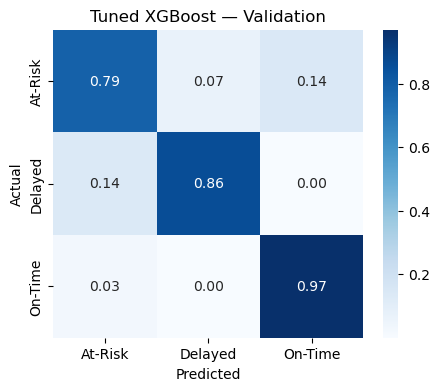

In [139]:
cm = confusion_matrix(y_val, y_val_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=["At-Risk","Delayed","On-Time"],
    yticklabels=["At-Risk","Delayed","On-Time"]
)

plt.title("Tuned XGBoost — Validation")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#### Hyperparameter tuning for Random Forest SMOTE version

In [140]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

pipe_rf_tune = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

In [141]:
param_grid_rf = {

    "model__n_estimators": [200, 400],

    "model__max_depth": [None, 10, 20],

    "model__min_samples_split": [2, 5],

    "model__min_samples_leaf": [1, 2],

    "model__max_features": ["sqrt", "log2"]
}

In [142]:
from sklearn.model_selection import GridSearchCV

grid_rf = GridSearchCV(

    estimator=pipe_rf_tune,

    param_grid=param_grid_rf,

    scoring="f1_macro",

    cv=5,

    n_jobs=-1,

    verbose=2
)

grid_rf.fit(X_train_main, y_train_main)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], ...}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [143]:
print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest CV Macro F1:")
print(grid_rf.best_score_)

Best Parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 400}

Best CV Macro F1:
0.8652469966965357


In [144]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

best_rf = grid_rf.best_estimator_

y_val_pred_rf = best_rf.predict(X_val)

print("\nValidation Accuracy:",
      accuracy_score(y_val, y_val_pred_rf))

print("\nValidation Macro F1:",
      f1_score(y_val, y_val_pred_rf, average="macro"))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_rf))


Validation Accuracy: 0.9232360376924845

Validation Macro F1: 0.863708972807561

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.78      0.75      1305
           1       0.87      0.88      0.87       870
           2       0.97      0.96      0.97      6527

    accuracy                           0.92      8702
   macro avg       0.86      0.87      0.86      8702
weighted avg       0.93      0.92      0.92      8702


Confusion Matrix:
[[1014  113  178]
 [ 106  764    0]
 [ 266    5 6256]]


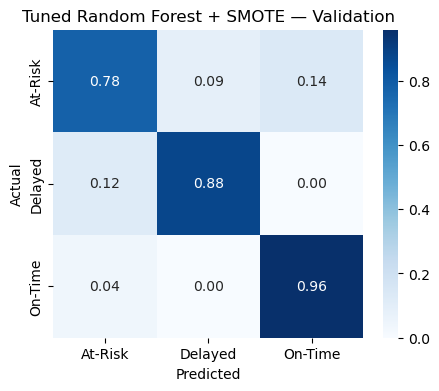

In [145]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred_rf)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=["At-Risk","Delayed","On-Time"],
    yticklabels=["At-Risk","Delayed","On-Time"]
)

plt.title("Tuned Random Forest + SMOTE — Validation")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [146]:
print(grid_xgb.best_params_)
print(grid_xgb.best_score_)

{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 8, 'model__n_estimators': 200, 'model__subsample': 0.8}
0.8722137288708016


In [147]:
print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 400}
0.8652469966965357


### Final Model Saving

In [148]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42,
        
        colsample_bytree=0.8,
        learning_rate=0.03,
        max_depth=8,
        n_estimators=200,
        subsample=0.8
    ))
])

In [150]:
final_model.fit(X_train, y_train_encoded)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [151]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

y_test_pred = final_model.predict(X_test)

print("FINAL TEST RESULTS\n")

print("Accuracy:",
      round(accuracy_score(y_test_encoded, y_test_pred),4))

print("Macro F1:",
      round(f1_score(y_test_encoded, y_test_pred, average="macro"),4))

print("\nClassification Report:")
print(classification_report(y_test_encoded, y_test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_encoded, y_test_pred))

FINAL TEST RESULTS

Accuracy: 0.9339
Macro F1: 0.8777

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78      1306
           1       0.89      0.87      0.88       870
           2       0.97      0.97      0.97      6527

    accuracy                           0.93      8703
   macro avg       0.88      0.87      0.88      8703
weighted avg       0.93      0.93      0.93      8703


Confusion Matrix:
[[1019   92  195]
 [ 112  758    0]
 [ 176    0 6351]]


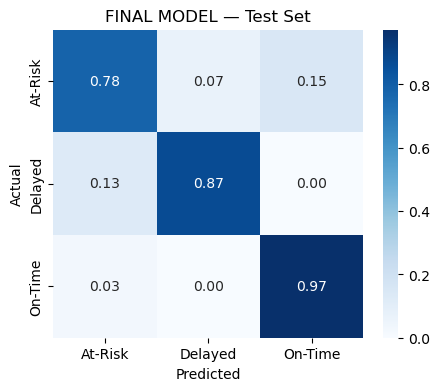

In [152]:
cm = confusion_matrix(y_test_encoded, y_test_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=["At-Risk","Delayed","On-Time"],
    yticklabels=["At-Risk","Delayed","On-Time"]
)

plt.title("FINAL MODEL — Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [153]:
import joblib

joblib.dump(final_model, "delivery_xgboost_model.pkl")

['delivery_xgboost_model.pkl']

In [154]:
final_results = pd.DataFrame([{
    "Model": "XGBoost Tuned",
    "Dataset": "Test Set",
    "Accuracy": accuracy_score(y_test_encoded, y_test_pred),
    "Macro F1": f1_score(y_test_encoded, y_test_pred, average="macro")
}])

final_results

,Model,Dataset,Accuracy,Macro F1
0,XGBoost Tuned,Test Set,0.933931,0.877654


### feature importance graph

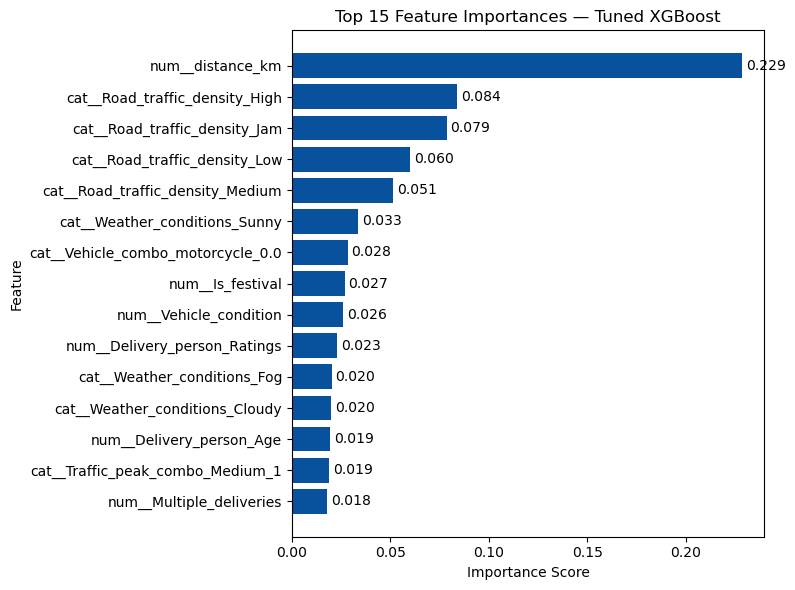

In [156]:
xgb_model = final_model.named_steps["model"]
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
importances = xgb_model.feature_importances_

# create dataframe
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# sort and take top 15
feat_imp = feat_imp.sort_values("Importance", ascending=False).head(15)

# plot horizontal bar chart
plt.figure(figsize=(8,6))

plt.barh(
    feat_imp["Feature"][::-1],
    feat_imp["Importance"][::-1],
    color="#08519c"
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances — Tuned XGBoost")

# add values on bars
for i, v in enumerate(feat_imp["Importance"][::-1]):
    plt.text(v + 0.002, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.show()